# Various utils and import, run once

Potentially do `pip install orjson ipywidgets` first and **restart the whole jupyter**

In [1]:
%%time

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


# Workaround to fix weird scroll-inducing whitespace at end of many cell's outputs.
from IPython.display import display_html, display
display_html("""<style>.jp-OutputArea { max-height: none !important; overflow-y: visible !important }</style>""", raw=True)



from functools import partial

def _no_useless_zeros(xstr):
    if "." in xstr:
        return xstr.rstrip("0").rstrip(".")
    return xstr

def nice_number_big(x, *_, decimal_places=1, base=1000, sep=''):
    for unit in ['', 'k', 'M', 'B', 'T']:
        if abs(x) < base or unit == 'T':
            break
        x /= base
    return _no_useless_zeros(f"{x:.{decimal_places}f}") + f"{sep}{unit}"

def nice_number(x, *_, decimal_places=1, base=1000, sep=''):
    if abs(x) >= 1:
        return nice_number_big(x, decimal_places=decimal_places, base=base, sep=sep)

    if x == 0:  # Avoid log10 issue below.
        return "0"

    if -np.log10(abs(x)) <= decimal_places:  # 0.1 for 1, 0.01 for 2, etc.
        return _no_useless_zeros(f"{x:.{decimal_places}f}")

    # Smaller than 0.1, let's go to scientific notation for that.
    return f"{x:.{decimal_places}e}"



from concurrent.futures import ThreadPoolExecutor

def paralist(items, func, max_workers=None):
    with ThreadPoolExecutor(max_workers) as executor:
        return executor.map(func, items)

def paradict(keys, func, max_workers=None):
    with ThreadPoolExecutor(max_workers) as executor:
        results = executor.map(func, keys)
    return dict(zip(keys, results))

def procadict(keys, func, max_workers=None, chunksize=1):
    from concurrent.futures import ProcessPoolExecutor
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        results = executor.map(func, keys, chunksize=chunksize)
    return dict(zip(keys, results))



def what_varies(configs, ignore=("name", "xid", "wid", "jid")):
    all_keys = set(k for c in configs.values() for k in c) - set(ignore)
    for k in all_keys:
        all_values = {str(c.get(k)): c.get(k) for c in configs.values()}
        if len(all_values) != 1:
            vals = sorted(all_values.values(), key=lambda v: (v is None, v))
            print(f"{k} has values: {vals}")



# Set of group highlighting algos:
def max_last(xys):
    lasty = [y[np.argmax(x)] for x, y, *_ in xys]
    return {np.argmax(lasty)}

def min_last(xys):
    lasty = [y[np.argmax(x)] for x, y, *_ in xys]
    return {np.argmin(lasty)}

def max_peak(xys):
    peaks = [np.max(y) for x, y, *_ in xys]
    return {np.argmax(peaks)}

def min_low(xys):
    lows = [np.min(y) for x, y, *_ in xys]
    return {np.argmin(lows)}

def none(xys):
    return set(range(len(xys)))



import re
import json
from functools import cache

import orjson
import pandas as pd

@cache
def recomp(reg):
    return re.compile(reg)

# Faster than the pandas way.
# I also checked: compiled regex are faster than fnmatch's globs
@cache
def read(r, drop=("gnorm/.*", "pnorm/.*"), as_df=True):
    regs = tuple(map(recomp, drop))

    # For a ~large file, this is 1.7s with drop, 700ms without drop.
    # So we spend a lot in regex matching.
    def delkeys(d):  # Faster than the equivalent comprehension in case of no regs.
        for k in tuple(d):
            if any(r.fullmatch(k) for r in regs):
                del d[k]
        return d

    def load(line):  # Exceptions are almost free in Python, so this isn't slower.
        try:
            row = orjson.loads(line)
        except orjson.JSONDecodeError:
            row = json.loads(line)  # NaN/+-Inf not supported by orjson
        if regs and not as_df:
            row = delkeys(row)
        return row

    metrics = list(map(load, open(WORKDIRS + r + "/metrics.jsonl", "rb", buffering=8<<20)))
    
    if as_df:
        metrics = pd.DataFrame(metrics)
    
        def delkeys(df):
            if not regs: return df
            to_drop = [c for c in df.columns if any(r.fullmatch(str(c)) for r in regs)]
            df.drop(columns=to_drop, inplace=True)
            return df
        metrics = delkeys(metrics)

    return metrics



import numpy as np
from functools import cache

def xy(metrics, yname, xname="step", dropna=True):
    if isinstance(metrics, pd.DataFrame):
        x = metrics[xname].values
        y = metrics[yname].values
    else:
        x = np.array([m[xname] for m in metrics])  # if xname != "step" else np.arange(len(m))
        y = np.array([m[yname] for m in metrics])

    if dropna:  # Actually in the non-dataframe way, we can differentiate between logged NaN, and not present.
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

    return x, y

@cache
def xym(metric_name, yname, xname="step"):
    return xy(metrics[metric_name], yname, xname)

# TODO: Maybe need a much smarter smoothing based on xrange?
def smooth(x, y, nbins, mid=np.mean, lo=np.min, hi=np.max):
    x, y = np.asarray(x), np.asarray(y)
    if nbins is None or nbins < 1 or len(x) <= 2 * nbins:
        return x, y, None, None

    bins = np.linspace(np.nanmin(x), np.nanmax(x), nbins + 1)
    bin_indices = np.clip(np.digitize(x, bins) - 1, 0, len(bins) - 2)

    # Next we really just want to iterate over bins, for each bin collect mid/hi/lo.
    # However, naively that's O(nbins * npoints). Instead, we can pre-sort the bin_indices
    # once, and then go over the boundary chunks. This is only O(npoints log npoints).
    # In practice it's reducing ~12s for a huge dataset to 4s, which is nice!
    order = np.argsort(bin_indices, kind="mergesort")
    x_sorted = x[order]
    y_sorted = y[order]
    boundaries = np.r_[0, np.where(np.diff(bin_indices[order]) != 0)[0] + 1, len(order)]

    xmid, ymid, ylo, yhi = [], [], [], []
    for start, stop in zip(boundaries[:-1], boundaries[1:]):
        chunk_x = x_sorted[start:stop]
        chunk_y = y_sorted[start:stop]
        xmid.append(np.nanmean(chunk_x))
        ymid.append(mid(chunk_y))
        ylo.append(lo(chunk_y))
        yhi.append(hi(chunk_y))

    return np.asarray(xmid), np.asarray(ymid), np.asarray(ylo), np.asarray(yhi)

@cache
def xyms(metric_name, yname, xname="step", width=0, mid=np.nanmean, lo=np.nanmin, hi=np.nanmax):
    return smooth(*xy(metrics[metric_name], yname, xname), nbins=width, mid=mid, lo=lo, hi=hi)



# m = read(next(iter(configs.keys())), ())
# m = read(next(iter(configs.keys())))
# print(len(m))

CPU times: user 477 ms, sys: 165 ms, total: 642 ms
Wall time: 875 ms


# Load jobs and configs

In [2]:
XIDs = [  # NOTE: These example XIDs are OLD runs, if you try them, then use the "OLD runs" line below.
    '1114_225004',  # New sweep about finevision
    '1117_134621',  # Extension of above.
]

WORKDIRS = "/checkpoint/rigi/bv2/workdirs/"

# Get all those workdirs which actually ran:
runs = [f.removeprefix(WORKDIRS).removesuffix("/metrics.jsonl")
        # for xid in XIDs for f in glob.glob(f'{WORKDIRS}/*-{xid}-*/metrics.jsonl')]  # OLD runs
        # for xid in XIDs for f in glob.glob(f'{WORKDIRS}/*{xid}/*/metrics.jsonl')]  # NEW runs
        for xid in XIDs for f in glob.glob(f'{WORKDIRS}/*{xid}/*/metrics.jsonl') + glob.glob(f'{WORKDIRS}/*-{xid}-*/metrics.jsonl')]  # BOTH


configs = paradict(runs, lambda r: json.load(open(WORKDIRS + r + "/config.json")))
len(configs)

80

In [3]:
# Optionally add extra filds to the config, like `annotate` in xolab.

# TODO: make nicer API, integrate in loading.

def annotate(run_name, c):
    # Just an example of adding extra config fields to runs manually:
    if '1021_131121' in run_name:
        c['gpus'] = 8
    if '1021_124921' in run_name:
        c['gpus'] = 2

    c['relwd'] = round(c['wd'] / c['lr'], ndigits=10)

    # Example of just making something nicer:
    if "data.first_N" in c:
        c['dataN'] = nice_number(c['data.first_N'])

    # Example of adding defaults that are absent in earlier sweeps:
    c['model.head_dim'] = c.get('model.head_dim', 128)
    return c

def annotate_do(run_name, c):
    match (c.get('model.dropout.res_att'), c.get('model.dropout.res_mlp')):
        case (0, 0): c['dropout'] = "No"
        case (0.1, 0.1): c['dropout'] = "Two"
        case _:  c['dropout'] = "One"
    return c

# Uncomment to activate:
configs = {k: annotate(k, v) for k, v in configs.items()}

In [4]:
# Optionally filter the set of runs to load based on config settings

def filter_early(c):
    if c["xid"] == "1024_231914" and c["wid"] == 126:
        return False  # => drop this one
    return True  # => Keep all others

configs = {k: v for k, v in configs.items() if filter_early(v)}

In [5]:
print(f"Loaded {len(configs)} runs\n=== What varies: ===")
what_varies(configs)

Loaded 80 runs
=== What varies: ===
model.depth has values: [2, 4, 8, 12]
model.dim has values: [512, 768, 1024, 2048]
lr has values: [1e-05, 3e-05, 0.0001, 0.0003, 0.001]
wd has values: [1.0000000000000002e-06, 3e-06, 1e-05, 2.9999999999999997e-05, 0.0001]
model.kv_reduce has values: [2, 3, 4]


# Load metrics

In [6]:
%%time

# NOTE: When reloading data, need to invalidate any @cache'd things.
# Comment these lines to reuse metrics loaded previously instead of re-loading them.
read.cache_clear()
xyms.cache_clear()
xym.cache_clear()

metrics = procadict(configs, partial(read, as_df=True), max_workers=128)  # I get killed with 64 workers, so 4 it is.

print(f"Row count: {sum(map(len, metrics.values())):_}")
print(f"Col count: {len(set.union(*[set(df.columns) for df in metrics.values()]))}")

Row count: 8_000_000
Col count: 597
CPU times: user 11.1 s, sys: 1min 16s, total: 1min 27s
Wall time: 2min 1s


In [7]:
# Option to derive new metrics based on existing ones here.

def augment_metrics_(df, name):
    if len(df) in (0, 1):
        print(f"Broken job {name}")
    else:
        df['chrono/walltime_rel'] = df['chrono/steptime'].cumsum()
        df['chrono/walltime_rel_h'] = df['chrono/steptime'].cumsum() / 60 / 60

for k, v in metrics.items():
    augment_metrics_(v, k)

print("Updated col count:", len(set.union(*[set(df.columns) for df in metrics.values()])))

Updated col count: 599


## Find metric names

In [8]:
import ipywidgets as widgets

ykey, xkey = globals().get("ykey", "train/loss"), globals().get("xkey", "step")
all_metrics = sorted(set().union(*[df.columns.to_list() for df in metrics.values()]))

def filter_list(change, selector):
    selector.options = [n for n in all_metrics if change['new'].lower() in n.lower()]

def on_select_change(change, varname):
    print(varname, change)
    globals()[varname] = change['new']

ykey_search = widgets.Text(placeholder='Type to filter...', description='ykey:')
ykey_select = widgets.Select(options=all_metrics, rows=10, value=ykey if ykey in all_metrics else None)
ykey_search.observe(partial(filter_list, selector=ykey_select), names='value')
ykey_select.observe(partial(on_select_change, varname='ykey'), names='value')
ykey_box = widgets.VBox([ykey_search, ykey_select])

xkey_search = widgets.Text(placeholder='Type to filter...', description='xkey:')
xkey_select = widgets.Select(options=all_metrics, rows=10, value=xkey if xkey in all_metrics else None)
xkey_search.observe(partial(filter_list, selector=xkey_select), names='value')
xkey_select.observe(partial(on_select_change, varname='xkey'), names='value')
xkey_box = widgets.VBox([xkey_search, xkey_select])

side_by_side = widgets.HBox([ykey_box, xkey_box])
display(side_by_side)

# Flatboarding

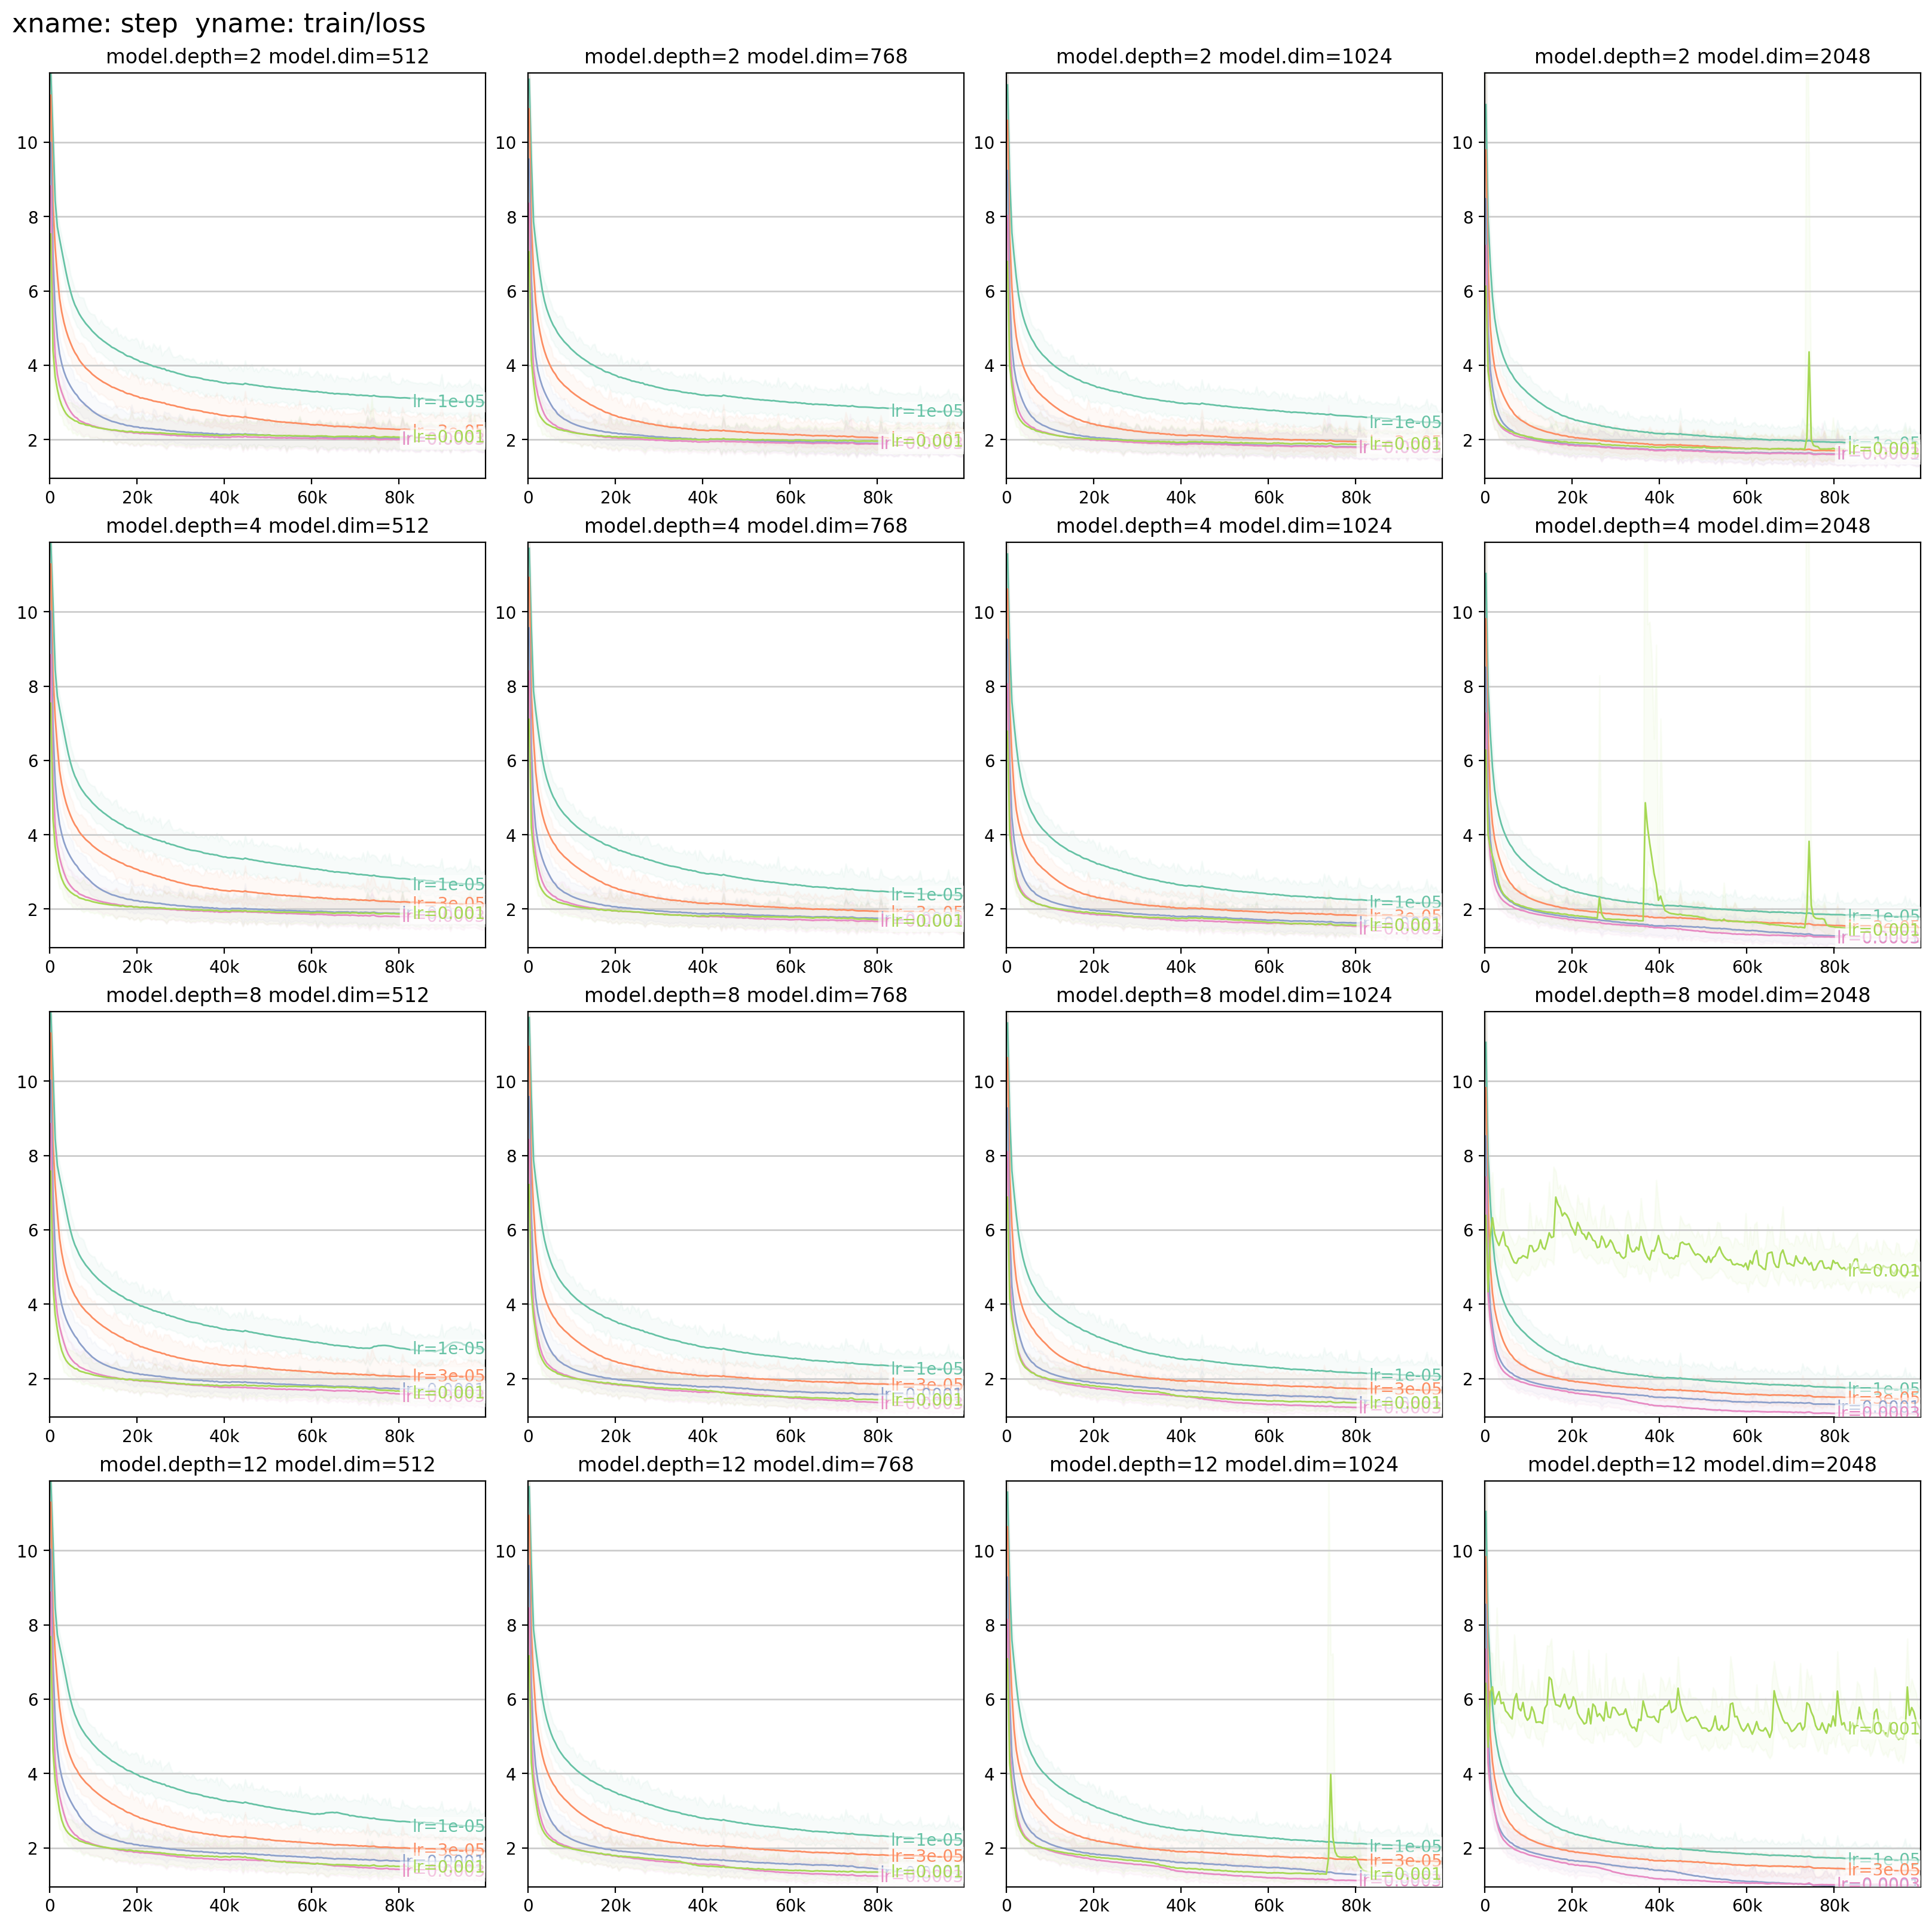

In [9]:
def flatboard(
    # configs, metrics,
    yname=ykey,
    xname=xkey,

    groupby=None,
    group_highlight=min_last,
    group_highlight_label=True,

    facetby=None,
    facet_cols=2,
    figwidth=None,  # Controls the whole figure width. None derives from cols.

    cmap=None,

    xlim="shared",  # None, or "shared", or (xmin, xmax)
    ylim="shared",  # None, or "shared", or (ymin, ymax)
    ylog=False, xlog=False,
    yfn=lambda y: y,  # Can be used for simply modifications of y, such as y * 100 for pct.

    smooth_bins=200,
    smooth_show_area=0.05,

    query=None,
    detect_bad=None,
    hide_bad=False,
):
    df = pd.DataFrame.from_dict(configs, orient="index")
    if query:
        df = df.query(query)
    # Turn non-string columns into strings now, for straightforward grouping.
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].astype("string")

    nfacets = len(df.groupby(facetby, dropna=False)) if facetby else 1
    ncols = min(nfacets, facet_cols)
    nrows = int(np.ceil(nfacets / ncols))
    figwidth = figwidth or (4 * ncols)

    fig, axes = plt.subplots(ncols=ncols, nrows=nrows, figsize=(figwidth, figwidth / ncols * nrows), layout="constrained", squeeze=False)
    for ax in axes.flat[nfacets:]:
        fig.delaxes(ax)

    _xlims = np.array([[np.inf, -np.inf]] * nfacets)
    _ylims = np.array([[np.inf, -np.inf]] * nfacets)

    ngroups = len(df.groupby(groupby, dropna=False)) if groupby else 1  # TODO: Could really do within facet, and then max across facets?
    cmap = cmap or (mpl.cm.Set2 if ngroups <= 8 else mpl.cm.tab20)

    for f, (fkey, fdf) in enumerate(df.groupby(facetby, dropna=False) if facetby else [("all", df)]):
        ax = axes.flat[f]

        if facetby:
            ax.set_title(' '.join(f"{p}={v}" for p, v in zip(facetby, fkey)), fontsize=12)

        for g, (gkey, gdf) in enumerate(fdf.groupby(groupby, dropna=False) if groupby else [("all", fdf)]):
            i_highlights = group_highlight([xyms(wid, yname, xname, smooth_bins) for wid in gdf.index])

            for i, wid in enumerate(gdf.index):
                x, y = xym(wid, yname, xname)
                y = yfn(y)

                if smooth_bins:
                    x, y, ym, yM = xyms(wid, yname, xname, smooth_bins)
                    y = yfn(y)
                    if smooth_show_area and i in i_highlights and ym is not None and yM is not None:
                        ax.fill_between(x, yfn(ym), yfn(yM), color=cmap(g), alpha=smooth_show_area)

                # Update limits, if shared limits were requested. Should come after smoothing!
                _xlims[f] = (min(_xlims[f][0], x.min()), max(_xlims[f][1], x.max()))
                _ylims[f] = (min(_ylims[f][0], y.min()), max(_ylims[f][1], y.max()))

                if i in i_highlights:
                    label = ' '.join(f"{p}={v}" for p, v in zip(groupby, gkey)) if groupby else wid
                    hlkw = dict(color=cmap(g), lw=1.0, alpha=1.0, label=label)
                else:
                    hlkw = dict(color=cmap(g), lw=0.5, alpha=0.3)

                if is_bad := (detect_bad is not None) and detect_bad(x, y):
                    if hide_bad:
                        continue
                    hlkw.update(color='red', lw=2.0, alpha=1.0)
                    print(wid)
                ax.plot(x, y, **hlkw)

                if group_highlight_label and i in i_highlights:
                    x1, y1 = x[np.argmax(x)], y[np.argmax(x)]
                    ax.text(x1, y1, label, ha='right', va='center', fontsize=10, color=cmap(g), clip_on=True,
                            bbox=dict(facecolor="white", alpha=0.5, edgecolor="none", boxstyle="round,pad=0.1"))
                    # TODO: To make it "always nice inside ax", we'd need to collect the limits in a first round,
                    # and add these labels in a second round.

    # Now compute the x/y lims for each plot according to the user setting.
    if xlim == "shared": xlim = ("shared", "shared")
    if ylim == "shared": ylim = ("shared", "shared")
    if xlim == None: xlim = (None, None)
    if ylim == None: ylim = (None, None)

    _xlims[:, 0] = np.min(_xlims[:, 0]) if xlim[0] == "shared" else np.nan if xlim[0] is None else xlim[0]
    _xlims[:, 1] = np.max(_xlims[:, 1]) if xlim[1] == "shared" else np.nan if xlim[1] is None else xlim[1]
    _ylims[:, 0] = np.min(_ylims[:, 0]) if ylim[0] == "shared" else np.nan if ylim[0] is None else ylim[0]
    _ylims[:, 1] = np.max(_ylims[:, 1]) if ylim[1] == "shared" else np.nan if ylim[1] is None else ylim[1]

    for ax, (xlo, xhi), (ylo, yhi) in zip(axes.flat, _xlims, _ylims):
        # Need to set log-scale before lims and formatters!
        ax.set_xscale('log' if xlog else 'linear')
        ax.set_yscale('log' if ylog else 'linear')
        ax.set_xlim(None if np.isnan(xlo) else xlo, None if np.isnan(xhi) else xhi)
        ax.set_ylim(None if np.isnan(ylo) else ylo, None if np.isnan(yhi) else yhi)

        ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(nice_number))
        ax.xaxis.set_minor_formatter(mpl.ticker.FuncFormatter(nice_number))
        ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(nice_number))
        ax.yaxis.set_minor_formatter(mpl.ticker.FuncFormatter(nice_number))

        ax.grid(which='major', axis='y', lw=1, c='#ccc')
        ax.grid(which='minor', axis='y', lw=1, ls='--', c='#ddd')

    fig.suptitle(f"xname: {xname}  yname: {yname}", fontsize=16, x=0, ha='left')
    return fig, axes

fig, axes = flatboard(
    # query="`model.dim` == 512",
    # query="`model.dropout.res_att` == 0.0 and `model.dropout.res_mlp` == 0.0",

    groupby=["lr"],
    group_highlight=min_last,  # Could also do max_last, or none, or others.

    facetby=["model.depth", "model.dim"],
    facet_cols=4,

    # Either: `None`, `"shared"`, or (min, max), where min/max are numbers or `None` or `"shared"`.
    xlim=(0, "shared"),  # None, or "shared", or (xmin, xmax)
    # ylim=(3000, 6000),  # None, or "shared", or (ymin, ymax)
    # ylim=(0, "shared"),  # None, or "shared", or (ymin, ymax)
    # ylog=True, xlog=False,
    # yfn=lambda y: y * 100,

    # detect_bad=lambda x, y: (np.nanmax(x) > 10_000 and  # Long enough
    #     (np.percentile(y[x > np.nanmax(x) - 5000], 10) > np.percentile(y[x < 5000], 10)  # End >> start
    #      or np.percentile(y[x > np.nanmax(x) - 5000], 10) > np.percentile(y, 10))),  # End >> overall best
    # hide_bad=True,
)

# Extensions - common tasks
Useful things done in relation with flatboarding somewhat commonly.

Tested less thoroughly/regularly than flatboarding above.

## Kill jobs

NOTE: This is currently over-complicated to find JobID, because we previously didn't link them correctly.
With recent new runs (as of 1 Nov), I (Lucas) should simplify this code a lot. Will do next time I need it.

In [ ]:
import re

jobids = !squeue -n {",".join(XIDs)} -O JobId
jobids = [line.strip() for line in jobids[1:]]

def get_job_workdir(jobid):
    workdirline = !head -200 /checkpoint/rigi/bv2/slurm_out/qkv/{jobid}.txt | grep 'Workdir: '
    workdirline = workdirline[0]
    if (groups := re.match(r".* Workdir: (\S*)", workdirline)):
        return groups.group(1)
    return None

job2wd = {jid: get_job_workdir(jid) for jid in jobids}
job2wd = {jid: wd for jid, wd in job2wd.items() if wd}

In [ ]:
to_kill = """
qkv-code-base-100k8gpu-1021_131121-6
qkv-code-base-100k8gpu-1021_131121-5
qkv-code-base-100k2gpu-1021_124921-4
qkv-code-base-100k8gpu-1021_131121-4
qkv-code-base-100k2gpu-1021_124921-9
qkv-code-base-100k8gpu-1021_131121-9
qkv-code-base-100k8gpu-1021_131121-8
qkv-code-base-100k2gpu-1021_124921-13
qkv-code-base-100k8gpu-1021_131121-13
qkv-code-base-100k2gpu-1021_124921-12
qkv-code-base-100k8gpu-1021_131121-12
qkv-code-base-100k2gpu-1021_124921-17
qkv-code-base-100k8gpu-1021_131121-17
qkv-code-base-100k2gpu-1021_124921-16
qkv-code-base-100k8gpu-1021_131121-16
qkv-code-base-100k2gpu-1021_124921-20
qkv-code-base-100k8gpu-1021_131121-20
qkv-code-base-100k8gpu-1021_131121-25
qkv-code-base-100k2gpu-1021_124921-24
"""

jids_to_kill = []
for k in to_kill.strip().split():
    for jid, wd in job2wd.items():
        if wd.endswith(k):
            jids_to_kill.append(jid)

print("scancel", *jids_to_kill)

## Show a specific job

In [ ]:
df = augment_configs(pd.DataFrame(configs).T)
df.query("`model.depth`==32 and `model.dim` == 4096")

## Print best THING per GROUPBY

In [ ]:
df = augment_configs(pd.DataFrame(configs).T)
df = df.query("relwd < 1")

groupby = ["model.dim", "model.depth", "lr"]
g = df.groupby(groupby)

for i, (gkey, gdf) in enumerate(g):
    gname = ' '.join(f"{p}={v}" for p, v in zip(groupby, gkey))
    best = min_last([xyms(wid, "loss/train/bits", "step", width=100) for wid in gdf.index])
    assert len(best) == 1
    print(f"{gname:45s} best relwd={gdf['relwd'].iloc[best.pop()]}")

## Experimental: Collect XIDs into zip

In [ ]:
XIDs = [
    '1024_231914',  # Code baselines, 8-gpu data subsets.
    '1027_104305',  # Single-job rerun
    '1027_120614',  # dim=512 with head_dim=64 (heads=2)
    '1027_120717',  # dim=512 with head_dim=32 (heads=4)
]

In [ ]:
import glob

WORKDIRS = "/checkpoint/rigi/bv2/workdirs/"

# Get all those workdirs which actually ran:
runs = [f.removeprefix(WORKDIRS).removesuffix("/metrics.jsonl")
        for xid in XIDs for f in glob.glob(f'{WORKDIRS}/*-{xid}-*/metrics.jsonl')]
len(runs)

In [ ]:
def paradict(keys, func, max_workers=None):
    from concurrent.futures import ThreadPoolExecutor
    with ThreadPoolExecutor(max_workers) as executor:
        results = executor.map(func, keys)
    return dict(zip(keys, results))

def procadict(keys, func, max_workers=None, chunksize=1):
    from concurrent.futures import ProcessPoolExecutor
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        results = executor.map(func, keys, chunksize=chunksize)
    return dict(zip(keys, results))

In [ ]:
import json

configs = paradict(runs, lambda r: json.load(open(WORKDIRS + r + "/config.json")))
len(configs)

In [ ]:
%%time
# %%timeit
import orjson
from functools import cache

@cache
def compregs(*regs):
    return tuple(re.compile(r) for r in regs)

# Faster than the pandas way.
# I also checked: compiled regex are faster than fnmatch's globs
def read(r, drop_res=("gnorm/.*", "pnorm/.*")):
    regs = compregs(*drop_res)

    # For a ~large file, this is 1.7s with drop, 700ms without drop.
    # So we spend a lot in regex matching.
    def delkeys(d):  # Faster than the comprehension in case of no regs.
        for k in tuple(d):
            if any(r.fullmatch(k) for r in regs):
                del d[k]
        return d

    def load(line):  # Exceptions are almost free in Python, so this isn't slower.
        try:
            row = orjson.loads(line)
        except orjson.JSONDecodeError:
            # print(f"orjson bailed on line: {line}")
            row = json.loads(line)  # NaN/+-Inf not supported by orjson
        return delkeys(row)

    # return [json.loads(line) for line in io.BufferedReader(open(WORKDIRS + r + "/metrics.jsonl", "rb"))]
    # return list(map(json.loads, io.BufferedReader(open(WORKDIRS + r + "/metrics.jsonl", "rb"))))
    # return [{k: v for k, v in orjson.loads(line).items() if any(r.fullmatch(k) for r in regs)}
            # for line in io.BufferedReader(open(WORKDIRS + r + "/metrics.jsonl", "rb"))]
    # return list(map(delkeys, map(orjson.loads, io.BufferedReader(open(WORKDIRS + r + "/metrics.jsonl", "rb")))))
    return list(map(load, io.BufferedReader(open(WORKDIRS + r + "/metrics.jsonl", "rb"))))

# m = read(next(iter(configs.keys())), drop=())
m = read(next(iter(configs.keys())))

In [ ]:
%%time
metrics = procadict(configs, read, max_workers=8)  # I get killed with 64 workers, so 4 it is.

print("Row count:", sum(map(len, metrics.values())))
print("Col count:", len(set().union(*(set().union(*v) for v in metrics.values()))))
# print("Col count:", len(set.union(*[set(df.columns) for df in metrics.values()])))

In [ ]:
import json

def short_float(x, digits=5):
    """Just cut off precision from floats. This is the only API that somewhat works.
       though not 100%: it doesn't shorten large numbers, try 123456789.0"""
    if isinstance(x, float):
        return float(f"{x:.{digits}g}")
    elif isinstance(x, dict):
        return {k: short_float(v, digits=digits) for k, v in x.items()}
    elif isinstance(x, list):
        return [short_float(v, digits=digits) for v in x]
    return x

data = {"pi": [123456789., 1.0, 0.0, 0.1, 0.3, 3e-4, 3e-5, 3e-6, 3e-7], "e": 2.718281828, "nums": [1.23456, 7.89012]}
print(json.dumps(short_float(data, 2)))

In [ ]:
with zipfile.ZipFile(f"experiment.zip", "w", compression=zipfile.ZIP_DEFLATED, compresslevel=9) as f:
    for i, run in enumerate(configs):
        print(f"\rWriting run {i} of {len(configs)}: {run}", flush=True, end='')
        f.writestr(f'{run}/config.json', json.dumps(configs[run]))
        f.writestr(f'{run}/metrics.jsonl', "\n".join(json.dumps(short_float(l)) for l in metrics[run]))

In [ ]:
def human(n): 
    for u in ['B','KB','MB','GB','TB']: 
        if n < 1024: return f"{n:.2f} {u}"
        n /= 1024
    return f"{n:.2f} PB"

with zipfile.ZipFile('experiment.zip') as zf:
    files, unc, comp = 0, 0, 0
    for info in zf.infolist():
        files += 1; unc += info.file_size; comp += info.compress_size
    print(f"{files} files, {human(unc)} uncompressed, {human(comp)} compressed: {(1 - comp / unc):.1%}")